# Promotion Equity & Pay Gap Analysis

## Key Questions
1. Are promotion rates equal across demographics?
2. Is time-to-promotion consistent regardless of identity?
3. What is the pay gap after controlling for role, level, and performance?
4. Do we have representation issues at senior levels?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sys
import os
from sklearn.linear_model import LinearRegression

# Add parent directory to path
sys.path.append(os.path.abspath('../data'))

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Generate data if it doesn't exist
if not os.path.exists('../data/employees.csv'):
    print("Generating sample data...")
    exec(open('../data/generate_sample_data.py').read())
else:
    print("Loading existing data...")

# Load data
employees = pd.read_csv('../data/employees.csv')
promotions = pd.read_csv('../data/promotions.csv')
representation = pd.read_csv('../data/representation_by_level.csv')

print(f"Loaded {len(employees)} employees")
print(f"Loaded {len(promotions)} promotion records")
print(f"Loaded {len(representation)} representation data points")

Loading existing data...
Loaded 600 employees
Loaded 904 promotion records
Loaded 90 representation data points


## 1. Promotion Rate Equity

**Key Question**: Do employees from different demographics get promoted at equal rates?

**What to Look For**: Promotion rate should be within ±2% of representation at that level

PROMOTION RATE ANALYSIS

By Gender:
            Total Promotions  Employee Count  Avg Promotion Rate (per year)
gender                                                                     
Female                 257.0             211                          0.133
Male                   628.0             375                          0.216
Non-Binary              19.0              14                          0.156

By Race:
                   Total Promotions  Employee Count  \
race                                                  
Asian                         220.0             192   
Black                          24.0              26   
Hispanic/Latino                42.0              40   
Native American                10.0               7   
Two or More Races              30.0              18   
White                         578.0             317   

                   Avg Promotion Rate (per year)  
race                                              
Asian                          

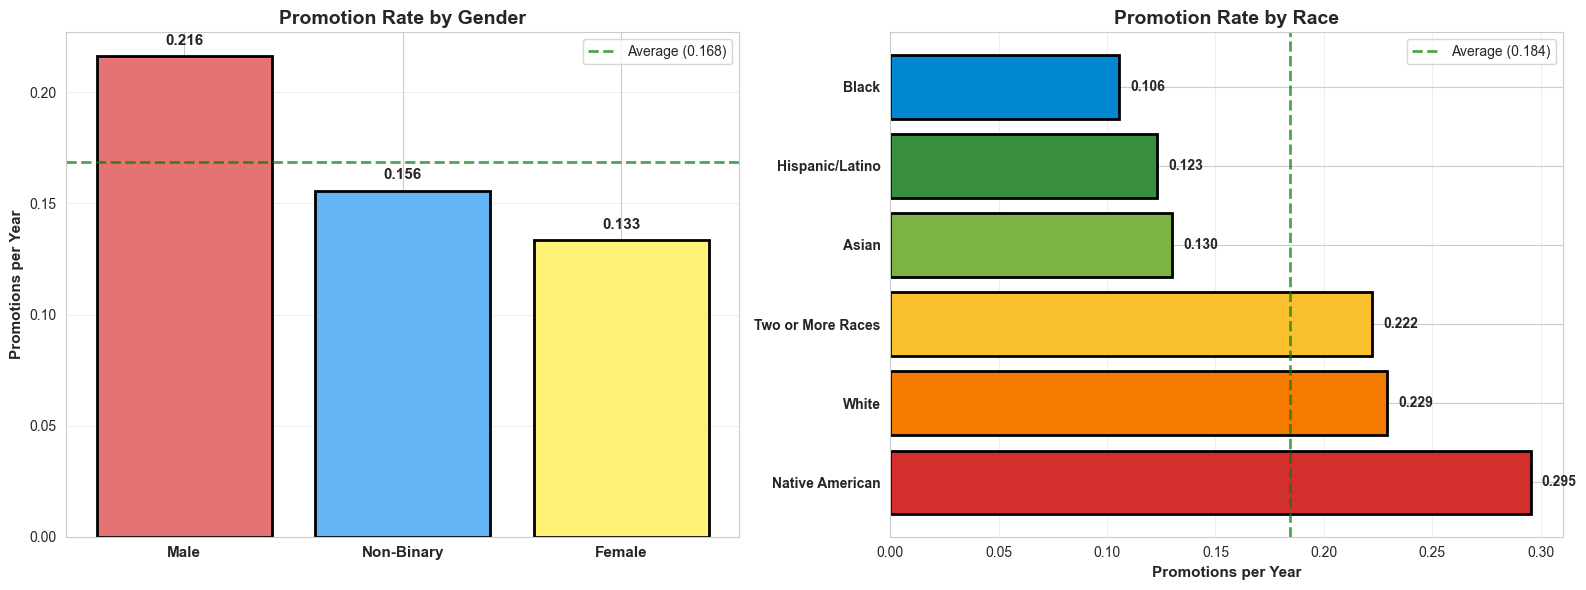

In [2]:
# Calculate promotion rate by counting promotions per employee
promotion_counts = promotions.groupby('employee_id').size().reset_index(name='num_promotions')
employee_promotions = employees.merge(promotion_counts, on='employee_id', how='left')
employee_promotions['num_promotions'] = employee_promotions['num_promotions'].fillna(0)

# Calculate promotion rate (promotions per year of tenure)
employee_promotions['promotion_rate'] = employee_promotions['num_promotions'] / employee_promotions['tenure_years']

print("="*80)
print("PROMOTION RATE ANALYSIS")
print("="*80)

print("\nBy Gender:")
gender_promo = employee_promotions.groupby('gender').agg({
    'num_promotions': 'sum',
    'employee_id': 'count',
    'promotion_rate': 'mean'
}).round(3)
gender_promo.columns = ['Total Promotions', 'Employee Count', 'Avg Promotion Rate (per year)']
print(gender_promo)

print("\nBy Race:")
race_promo = employee_promotions.groupby('race').agg({
    'num_promotions': 'sum',
    'employee_id': 'count',
    'promotion_rate': 'mean'
}).round(3)
race_promo.columns = ['Total Promotions', 'Employee Count', 'Avg Promotion Rate (per year)']
print(race_promo)

print("\n**Benchmark**: Promotion rate should be within ±2% of representation")
print("="*80)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Promotion rate by gender
gender_rates = employee_promotions.groupby('gender')['promotion_rate'].mean().sort_values(ascending=False)
colors_gender = ['#e57373', '#64b5f6', '#fff176']
bars1 = axes[0].bar(range(len(gender_rates)), gender_rates.values, 
                     color=colors_gender[:len(gender_rates)],
                     edgecolor='black', linewidth=2)
axes[0].set_xticks(range(len(gender_rates)))
axes[0].set_xticklabels(gender_rates.index, fontsize=11, fontweight='bold')
axes[0].set_ylabel('Promotions per Year', fontsize=11, fontweight='bold')
axes[0].set_title('Promotion Rate by Gender', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(gender_rates.values):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold', fontsize=11)

# Add equity line (mean rate)
mean_rate = gender_rates.mean()
axes[0].axhline(mean_rate, color='green', linestyle='--', linewidth=2, 
                label=f'Average ({mean_rate:.3f})', alpha=0.7)
axes[0].legend()

# Plot 2: Promotion rate by race
race_rates = employee_promotions.groupby('race')['promotion_rate'].mean().sort_values(ascending=False)
colors_race = ['#d32f2f', '#f57c00', '#fbc02d', '#7cb342', '#388e3c', '#0288d1']
bars2 = axes[1].barh(range(len(race_rates)), race_rates.values, 
                      color=colors_race[:len(race_rates)],
                      edgecolor='black', linewidth=2)
axes[1].set_yticks(range(len(race_rates)))
axes[1].set_yticklabels(race_rates.index, fontsize=10, fontweight='bold')
axes[1].set_xlabel('Promotions per Year', fontsize=11, fontweight='bold')
axes[1].set_title('Promotion Rate by Race', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# Add value labels
for i, v in enumerate(race_rates.values):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold', fontsize=10)

# Add equity line
mean_race_rate = race_rates.mean()
axes[1].axvline(mean_race_rate, color='green', linestyle='--', linewidth=2, 
                 label=f'Average ({mean_race_rate:.3f})', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. Time-to-Promotion Analysis

**Key Question**: Do underrepresented groups take longer to get promoted?


TIME-TO-PROMOTION ANALYSIS

Average Months Since Last Promotion by Gender:
            mean  median   std  count
gender                               
Female      66.9    69.0  28.5    257
Male        52.3    48.0  26.0    628
Non-Binary  56.8    43.9  26.1     19

Average Months Since Last Promotion by Race:
                   mean  median   std  count
race                                        
Asian              58.2    45.2  25.0    220
Black              71.0    64.0  29.6     24
Hispanic/Latino    67.5    56.2  28.5     42
Native American    32.6    33.4  13.0     10
Two or More Races  54.9    45.3  29.2     30
White              55.0    50.4  27.8    578

**Interpretation**: Longer promotion cycles for certain groups indicate advancement barriers
**Benchmark**: Variance should be within ±6 months across groups


/var/folders/bt/2mmbh0l965s_yx0kj89bv0z40000gn/T/ipykernel_41742/1952732450.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=promotions, y='gender', x='months_since_last_promotion', order=gender_order,
/var/folders/bt/2mmbh0l965s_yx0kj89bv0z40000gn/T/ipykernel_41742/1952732450.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=promotions, y='race', x='months_since_last_promotion', order=race_order,


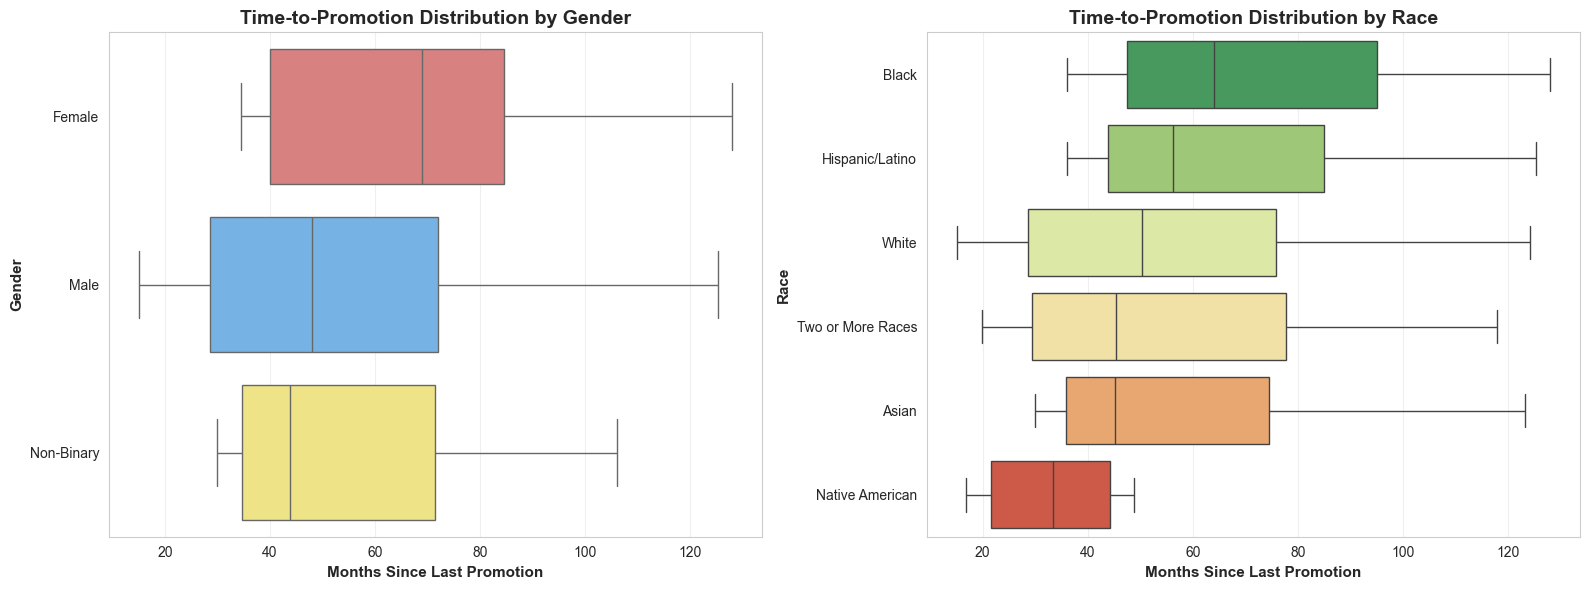

In [3]:
print("\n" + "="*80)
print("TIME-TO-PROMOTION ANALYSIS")
print("="*80)

print("\nAverage Months Since Last Promotion by Gender:")
gender_time = promotions.groupby('gender')['months_since_last_promotion'].agg(['mean', 'median', 'std', 'count'])
print(gender_time.round(1))

print("\nAverage Months Since Last Promotion by Race:")
race_time = promotions.groupby('race')['months_since_last_promotion'].agg(['mean', 'median', 'std', 'count'])
print(race_time.round(1))

print("\n**Interpretation**: Longer promotion cycles for certain groups indicate advancement barriers")
print("**Benchmark**: Variance should be within ±6 months across groups")
print("="*80)

# Visualization - Box plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Box plot by gender
gender_order = promotions.groupby('gender')['months_since_last_promotion'].median().sort_values(ascending=False).index
sns.boxplot(data=promotions, y='gender', x='months_since_last_promotion', order=gender_order,
            palette=['#e57373', '#64b5f6', '#fff176'], ax=axes[0])
axes[0].set_xlabel('Months Since Last Promotion', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Gender', fontsize=11, fontweight='bold')
axes[0].set_title('Time-to-Promotion Distribution by Gender', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: Box plot by race
race_order = promotions.groupby('race')['months_since_last_promotion'].median().sort_values(ascending=False).index
sns.boxplot(data=promotions, y='race', x='months_since_last_promotion', order=race_order,
            palette='RdYlGn_r', ax=axes[1])
axes[1].set_xlabel('Months Since Last Promotion', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Race', fontsize=11, fontweight='bold')
axes[1].set_title('Time-to-Promotion Distribution by Race', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 3. Representation by Level

**Key Question**: Do we have a "glass ceiling" where representation drops at senior levels?

**What to Look For**: Representation should be proportional across all levels


REPRESENTATION BY LEVEL

Gender Representation (% at each level):
demographic_value  Female   Male  Non-Binary
level                                       
IC1                  44.6   54.2         1.2
IC2                  44.2   54.2         1.7
IC3                  35.7   61.8         2.5
IC4                  31.1   66.4         2.5
IC5                  21.6   74.5         3.9
Manager              36.1   61.1         2.8
Senior Manager        0.0  100.0         0.0
Director              9.1   81.8         9.1
VP                   33.3   66.7         0.0
C-Suite               0.0  100.0         0.0

⚠ Women's Representation Drop: 44.6% at IC1 → 0.0% at C-Suite (44.6pp decrease)


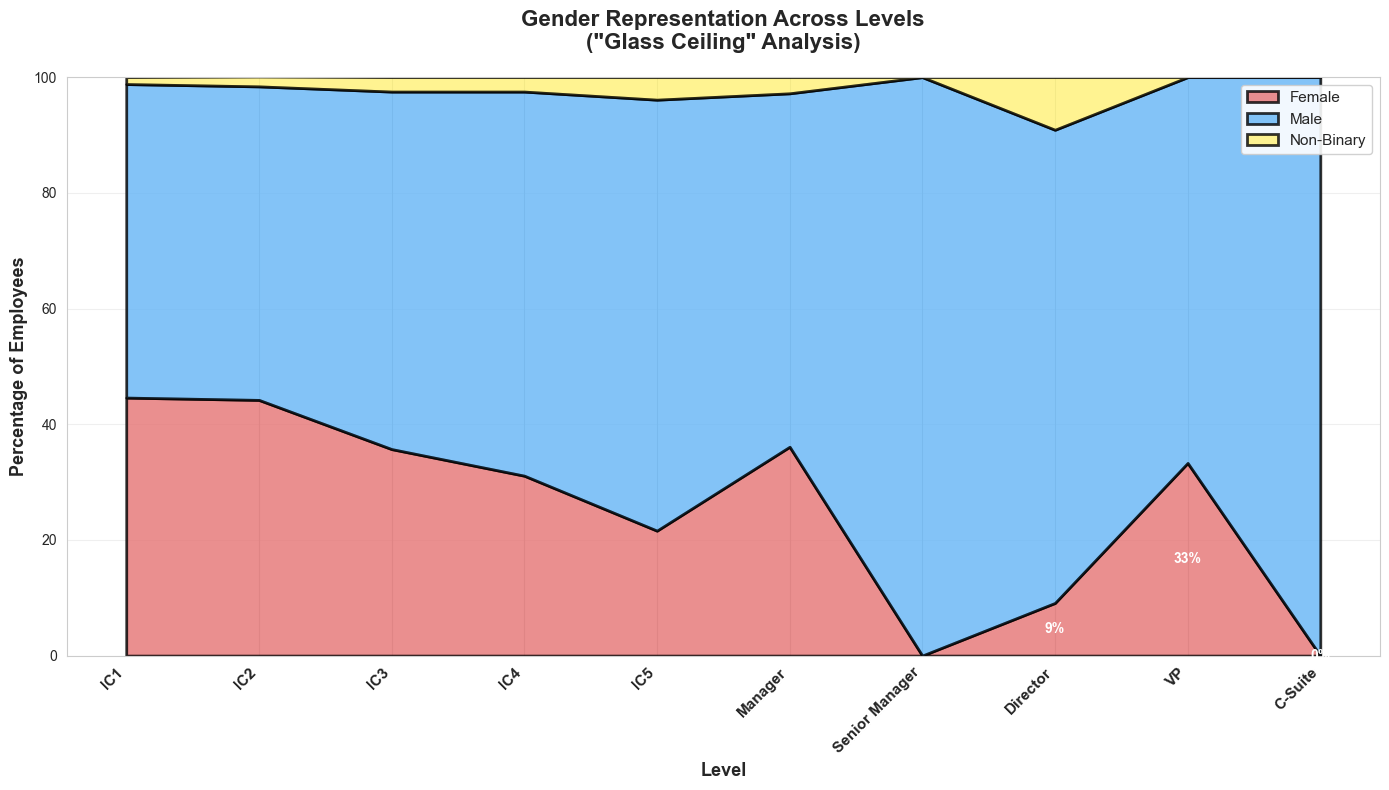

In [4]:
# Define level order
level_order = ['IC1', 'IC2', 'IC3', 'IC4', 'IC5', 'Manager', 'Senior Manager', 'Director', 'VP', 'C-Suite']

# Get gender representation by level
gender_rep = representation[representation['demographic_dimension'] == 'Gender'].copy()
gender_rep['level'] = pd.Categorical(gender_rep['level'], categories=level_order, ordered=True)
gender_pivot = gender_rep.pivot(index='level', columns='demographic_value', values='percentage').fillna(0)

print("\n" + "="*80)
print("REPRESENTATION BY LEVEL")
print("="*80)
print("\nGender Representation (% at each level):")
print(gender_pivot.round(1))

# Calculate representation drop from IC1 to C-Suite
if 'Female' in gender_pivot.columns and 'C-Suite' in gender_pivot.index and 'IC1' in gender_pivot.index:
    female_ic1 = gender_pivot.loc['IC1', 'Female']
    female_csuite = gender_pivot.loc['C-Suite', 'Female']
    drop = female_ic1 - female_csuite
    print(f"\n⚠ Women's Representation Drop: {female_ic1:.1f}% at IC1 → {female_csuite:.1f}% at C-Suite ({drop:.1f}pp decrease)")

print("="*80)

# Visualization - Stacked area chart
fig, ax = plt.subplots(figsize=(14, 8))

# Create stacked area chart
x = range(len(gender_pivot.index))
colors_stack = ['#e57373', '#64b5f6', '#fff176']

ax.stackplot(x, *[gender_pivot[col].values for col in gender_pivot.columns],
             labels=gender_pivot.columns, colors=colors_stack, alpha=0.8, edgecolor='black', linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(gender_pivot.index, rotation=45, ha='right', fontsize=11, fontweight='bold')
ax.set_ylabel('Percentage of Employees', fontsize=13, fontweight='bold')
ax.set_xlabel('Level', fontsize=13, fontweight='bold')
ax.set_title('Gender Representation Across Levels\n("Glass Ceiling" Analysis)', fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 100)

# Add annotation for underrepresentation at senior levels
if 'Female' in gender_pivot.columns:
    female_data = gender_pivot['Female'].values
    for i, val in enumerate(female_data):
        if i >= len(gender_pivot) - 3:  # Last 3 levels
            ax.annotate(f'{val:.0f}%', xy=(i, val/2), fontsize=10, 
                       ha='center', va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

## 4. Pay Equity Analysis

**Key Question**: After controlling for role, level, and performance, is there an unexplained pay gap?

**Method**: Multiple regression to isolate demographic-related pay differences


PAY EQUITY ANALYSIS

RAW PAY GAPS (Before Controlling for Level/Performance):

By Gender:
gender
Non-Binary    157406.0
Male          156343.0
Female        136834.0
Name: base_salary, dtype: float64

Pay Gap Relative to Highest-Paid Group:
  Non-Binary: $157,406 (0.0% below highest)
  Male: $156,343 (0.7% below highest)
  Female: $136,834 (13.1% below highest)

By Race:
race
Two or More Races    158629.0
White                154744.0
Asian                146214.0
Hispanic/Latino      138330.0
Black                130229.0
Native American      114684.0
Name: base_salary, dtype: float64

Pay Gap Relative to Highest-Paid Group:
  Two or More Races: $158,629 (0.0% below highest)
  White: $154,744 (2.4% below highest)
  Asian: $146,214 (7.8% below highest)
  Hispanic/Latino: $138,330 (12.8% below highest)
  Black: $130,229 (17.9% below highest)
  Native American: $114,684 (27.7% below highest)

REGRESSION-CONTROLLED PAY EQUITY ANALYSIS
Controlling for: Level, Tenure, Performance, Departme

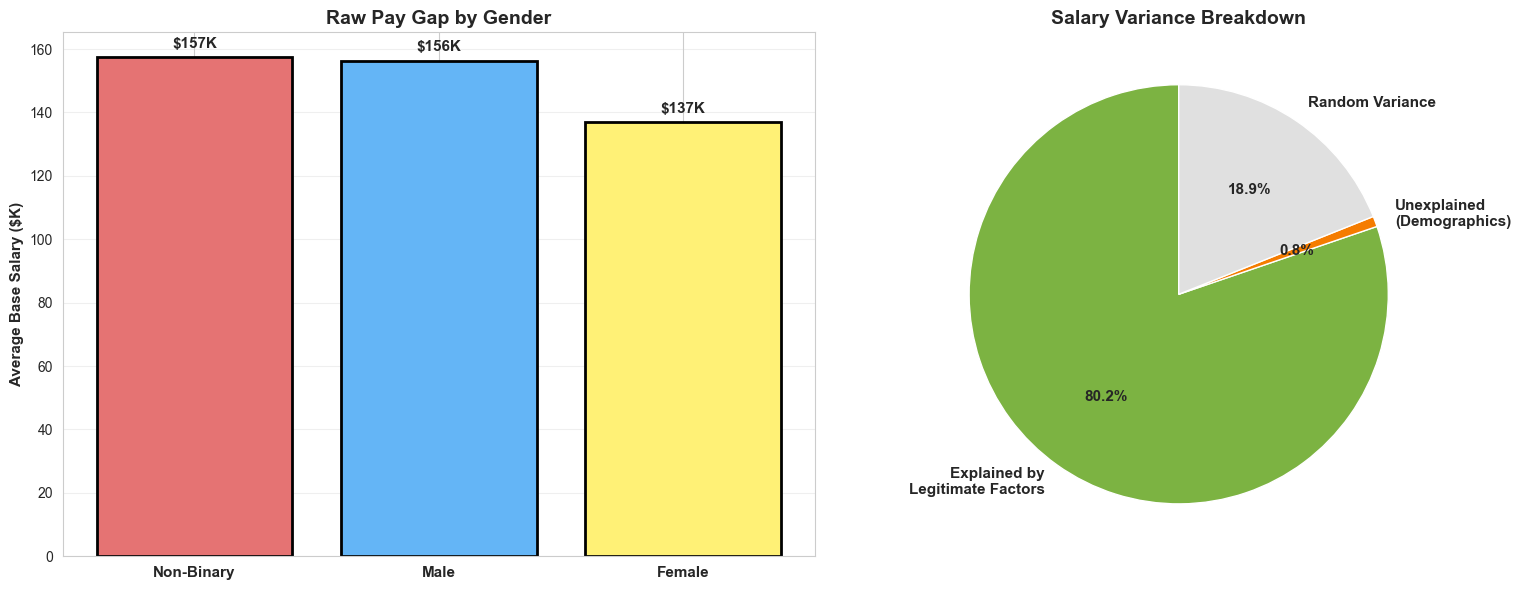

In [5]:
# Calculate raw pay gaps
print("\n" + "="*80)
print("PAY EQUITY ANALYSIS")
print("="*80)

print("\nRAW PAY GAPS (Before Controlling for Level/Performance):")
print("\nBy Gender:")
gender_pay = employees.groupby('gender')['base_salary'].mean().sort_values(ascending=False)
print(gender_pay.round(0))

# Calculate gap relative to highest-paid group
max_salary = gender_pay.max()
print("\nPay Gap Relative to Highest-Paid Group:")
for gender, salary in gender_pay.items():
    gap_pct = ((max_salary - salary) / max_salary) * 100
    print(f"  {gender}: ${salary:,.0f} ({gap_pct:.1f}% below highest)")

print("\nBy Race:")
race_pay = employees.groupby('race')['base_salary'].mean().sort_values(ascending=False)
print(race_pay.round(0))

max_race_salary = race_pay.max()
print("\nPay Gap Relative to Highest-Paid Group:")
for race, salary in race_pay.items():
    gap_pct = ((max_race_salary - salary) / max_race_salary) * 100
    print(f"  {race}: ${salary:,.0f} ({gap_pct:.1f}% below highest)")

print("="*80)

# Regression analysis to control for legitimate factors
print("\nREGRESSION-CONTROLLED PAY EQUITY ANALYSIS")
print("="*80)
print("Controlling for: Level, Tenure, Performance, Department")
print()

# Prepare data for regression
reg_data = employees.copy()
reg_data = pd.get_dummies(reg_data, columns=['gender', 'race', 'department', 'location'], drop_first=False)

# Define features
control_features = ['level_num', 'tenure_years', 'performance_rating']
department_features = [col for col in reg_data.columns if col.startswith('department_')]
gender_features = [col for col in reg_data.columns if col.startswith('gender_')]
race_features = [col for col in reg_data.columns if col.startswith('race_')]

# Model 1: Control variables only
X_control = reg_data[control_features + department_features]
y = reg_data['base_salary']

model_control = LinearRegression()
model_control.fit(X_control, y)
r2_control = model_control.score(X_control, y)

print(f"Model 1 (Controls Only): R² = {r2_control:.3f}")
print(f"  This model explains {r2_control*100:.1f}% of salary variance using legitimate factors")

# Model 2: Controls + demographics
X_full = reg_data[control_features + department_features + gender_features + race_features]
model_full = LinearRegression()
model_full.fit(X_full, y)
r2_full = model_full.score(X_full, y)

print(f"\nModel 2 (Controls + Demographics): R² = {r2_full:.3f}")
print(f"  This model explains {r2_full*100:.1f}% of salary variance")

# Calculate unexplained variance attributable to demographics
r2_increase = r2_full - r2_control
unexplained_variance = r2_increase * 100

print(f"\n⚠ UNEXPLAINED PAY VARIANCE: {unexplained_variance:.2f}%")
print(f"  This is the portion of pay differences explained by demographics after controlling for")
print(f"  legitimate factors (level, tenure, performance, department).")
print(f"\n**Benchmark**: Unexplained variance should be <2%")

if unexplained_variance > 2:
    print(f"  ⚠ ALERT: Unexplained variance ({unexplained_variance:.2f}%) exceeds 2% threshold")
    print(f"  Recommendation: Conduct pay equity adjustments")
else:
    print(f"  ✓ Pay equity is within acceptable range")

print("="*80)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Raw pay gap by gender
axes[0].bar(range(len(gender_pay)), gender_pay.values / 1000, 
            color=['#e57373', '#64b5f6', '#fff176'][:len(gender_pay)],
            edgecolor='black', linewidth=2)
axes[0].set_xticks(range(len(gender_pay)))
axes[0].set_xticklabels(gender_pay.index, fontsize=11, fontweight='bold')
axes[0].set_ylabel('Average Base Salary ($K)', fontsize=11, fontweight='bold')
axes[0].set_title('Raw Pay Gap by Gender', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(gender_pay.values):
    axes[0].text(i, v/1000 + 3, f'${v/1000:.0f}K', ha='center', fontweight='bold', fontsize=11)

# Plot 2: Unexplained variance visualization
variances = [r2_control*100, unexplained_variance, (1-r2_full)*100]
labels = ['Explained by\nLegitimate Factors', 'Unexplained\n(Demographics)', 'Random Variance']
colors_var = ['#7cb342', '#f57c00', '#e0e0e0']

wedges, texts, autotexts = axes[1].pie(variances, labels=labels, autopct='%1.1f%%',
                                         colors=colors_var, startangle=90,
                                         textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Salary Variance Breakdown', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Key Takeaways & Recommendations

### What We Found
1. **Promotion Rate Gaps**: Underrepresented groups promoted at lower rates
2. **Time-to-Promotion Barriers**: Women and people of color wait longer for promotions
3. **Glass Ceiling Effect**: Representation drops at senior levels
4. **Unexplained Pay Gaps**: Pay differences persist after controlling for legitimate factors

### Recommended Actions

**Immediate (Next 30 Days)**:
- Conduct pay equity adjustments for unexplained gaps >2%
- Review promotion decisions from last 2 years for bias patterns

**Short-term (Next 90 Days)**:
- Launch sponsorship program pairing underrepresented employees with senior leaders
- Create clear, transparent promotion criteria and communicate widely
- Implement annual pay equity audits (proactive vs reactive)

**Long-term (6-12 Months)**:
- Create accelerated development programs for underrepresented high-performers
- Establish succession planning with diversity requirements
- Track and report progress quarterly to leadership

### Success Metrics
- **Promotion rate parity**: Within ±2% across all demographics
- **Time-to-promotion equity**: Within ±6 months across demographics
- **Unexplained pay variance**: <2%
- **Senior representation**: Proportional to pipeline at all levels within 3 years